**1. Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


**2. Load the dataset**

In [3]:
df = pd.read_csv("COVID-19.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


**3. First look at the data**

In [4]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,AF,Afghanistan,EMR,NaN,0,NaN,0
1,2020-01-04,DZ,Algeria,AFR,NaN,0,NaN,0
2,2020-01-04,AL,Albania,EUR,NaN,0,NaN,0
3,2020-01-04,AI,Anguilla,AMR,NaN,0,NaN,0
4,2020-01-04,AS,American Samoa,WPR,0.0,0,0.0,0


In [5]:
df.tail()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
573355,2026-07-19,TK,Tokelau,WPR,NaN,80,NaN,0
573356,2026-07-19,WF,Wallis and Futuna,WPR,NaN,3760,NaN,9
573357,2026-07-19,VI,United States Virgin Islands,AMR,NaN,25389,NaN,132
573358,2026-07-19,TZ,United Republic of Tanzania,AFR,NaN,43655,NaN,846
573359,2026-07-19,VE,Venezuela (Bolivarian Republic of),AMR,NaN,552751,NaN,5856


**4. Dataset shape**

In [6]:
rows, columns = df.shape

print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {columns}")

Number of Rows    : 573,360
Number of Columns : 8


**5. Column information**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573360 entries, 0 to 573359
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date_reported      573360 non-null  object 
 1   Country_code       570971 non-null  object 
 2   Country            573360 non-null  object 
 3   WHO_region         573360 non-null  object 
 4   New_cases          214571 non-null  float64
 5   Cumulative_cases   573360 non-null  int64  
 6   New_deaths         156097 non-null  float64
 7   Cumulative_deaths  573360 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 35.0+ MB


**6. Column names**

In [8]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Columns:
1. Date_reported
2. Country_code
3. Country
4. WHO_region
5. New_cases
6. Cumulative_cases
7. New_deaths
8. Cumulative_deaths


**7. Data types**

In [9]:
df.dtypes.to_frame("Data Type")

,Data Type
Date_reported,object
Country_code,object
Country,object
WHO_region,object
New_cases,float64
Cumulative_cases,int64
New_deaths,float64
Cumulative_deaths,int64


**8. Statistical summary**

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date_reported,573360,2389,2020-01-04,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country_code,570971,239,AF,2389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,573360,240,Afghanistan,2389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_region,573360,7,EUR,148118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
New_cases,214571.0,NaN,NaN,NaN,3631.750078,48086.378106,-65079.0,2.0,57.0,652.5,6966046.0
Cumulative_cases,573360.0,NaN,NaN,NaN,2220612.821032,8990286.927592,0.0,7932.0,66391.0,703228.0,103436829.0
New_deaths,156097.0,NaN,NaN,NaN,45.587366,240.8016,-3520.0,0.0,2.0,14.0,44047.0
Cumulative_deaths,573360.0,NaN,NaN,NaN,22840.746278,90221.287165,0.0,49.0,830.0,8711.0,1238678.0


**9. Convert date column**

In [13]:
df['Date_reported'] = pd.to_datetime(df['Date_reported'])
print("Minimum date:", df['Date_reported'].min())
print("Maximum date:", df['Date_reported'].max())

Minimum date: 2020-01-04 00:00:00
Maximum date: 2026-07-19 00:00:00


**10. Check missing values**

In [17]:
df.isnull().sum()
display(missing)

,Missing_Count,Missing_Percentage
New_deaths,417263,72.775045
New_cases,358789,62.576566
Country_code,2389,0.416667
Date_reported,0,0.000000
WHO_region,0,0.000000
Country,0,0.000000
Cumulative_cases,0,0.000000
Cumulative_deaths,0,0.000000


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.nunique().sort_values(ascending=False)

Cumulative_cases     130942
Cumulative_deaths     41424
New_cases             18372
Date_reported          2389
New_deaths             1899
Country                 240
Country_code            239
WHO_region                7
dtype: int64

In [22]:
print("Number of countries:", df['Country'].nunique())

display(
    df['Country'].drop_duplicates().sort_values().to_frame())

Number of countries: 240


,Country
0,Afghanistan
2,Albania
1,Algeria
4,American Samoa
8,Andorra
...,...
232,Wallis and Futuna
220,Yemen
234,Zambia
224,Zimbabwe


**10. Distribution of records by WHO region**

In [70]:
display(df['WHO_region'].value_counts().to_frame('Number_of_Records'))

,Number_of_Records
WHO_region,
EUR,148118
AMR,129006
AFR,119450
WPR,86004
EMR,52558
SEAR,23890
OTHER,14334


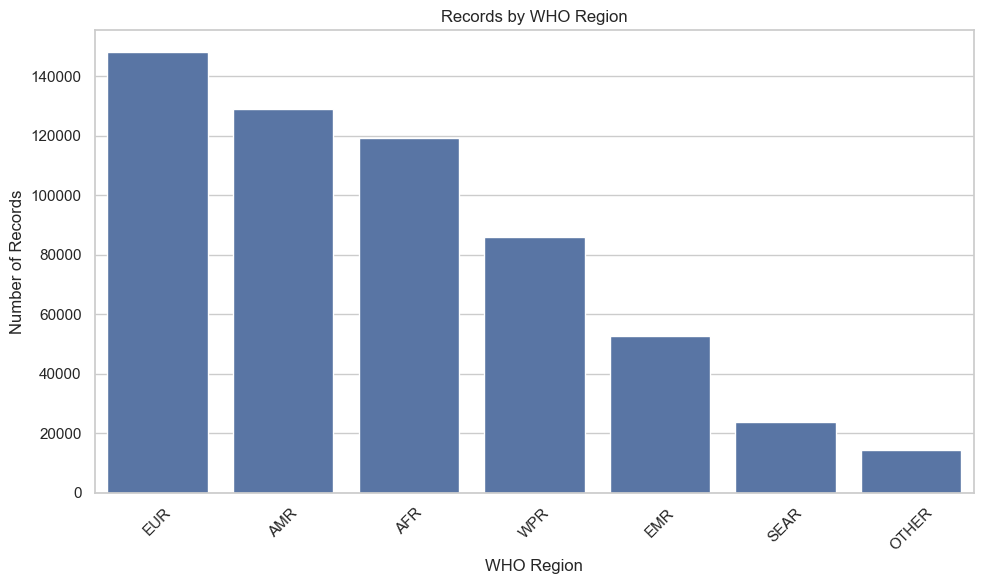

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='WHO_region',
    order=df['WHO_region'].value_counts().index
)

plt.title('Records by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**11. Total new cases**

In [25]:
total_new_cases = df['New_cases'].sum()

print(f"Total reported new cases: {total_new_cases:,.0f}")

Total reported new cases: 779,268,246


**12. Total deaths**

In [26]:
total_new_deaths = df['New_deaths'].sum()

print(f"Total reported new deaths: {total_new_deaths:,.0f}")

Total reported new deaths: 7,116,051


**13. Maximum daily cases**

In [27]:
max_cases = df['New_cases'].max()

print(f"Maximum new cases reported in a single record: {max_cases:,.0f}")

display(
    df[df['New_cases'] == max_cases]
)

Maximum new cases reported in a single record: 6,966,046


,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
260198,2022-12-23,CN,China,WPR,6966046.0,50447985,894.0,36318


**14. Maximum daily deaths**

In [28]:
max_deaths = df['New_deaths'].max()

print(f"Maximum new deaths reported in a single record: {max_deaths:,.0f}")

display(
    df[df['New_deaths'] == max_deaths]
)

Maximum new deaths reported in a single record: 44,047


,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
269794,2023-02-01,CN,China,WPR,55271.0,98527660,44047.0,113926


**15. Total cumulative cases by country**

In [29]:
country_cases = (
    df.groupby('Country')['Cumulative_cases']
      .max()
      .sort_values(ascending=False)
)

display(country_cases.head(20).to_frame('Total_Cases'))

,Total_Cases
Country,
United States of America,103436829
China,99381761
India,45056221
France,39060935
Germany,38437953
Brazil,38042729
Republic of Korea,34571873
Japan,33803572
Italy,26969918


**16. Top 10 countries by COVID cases**

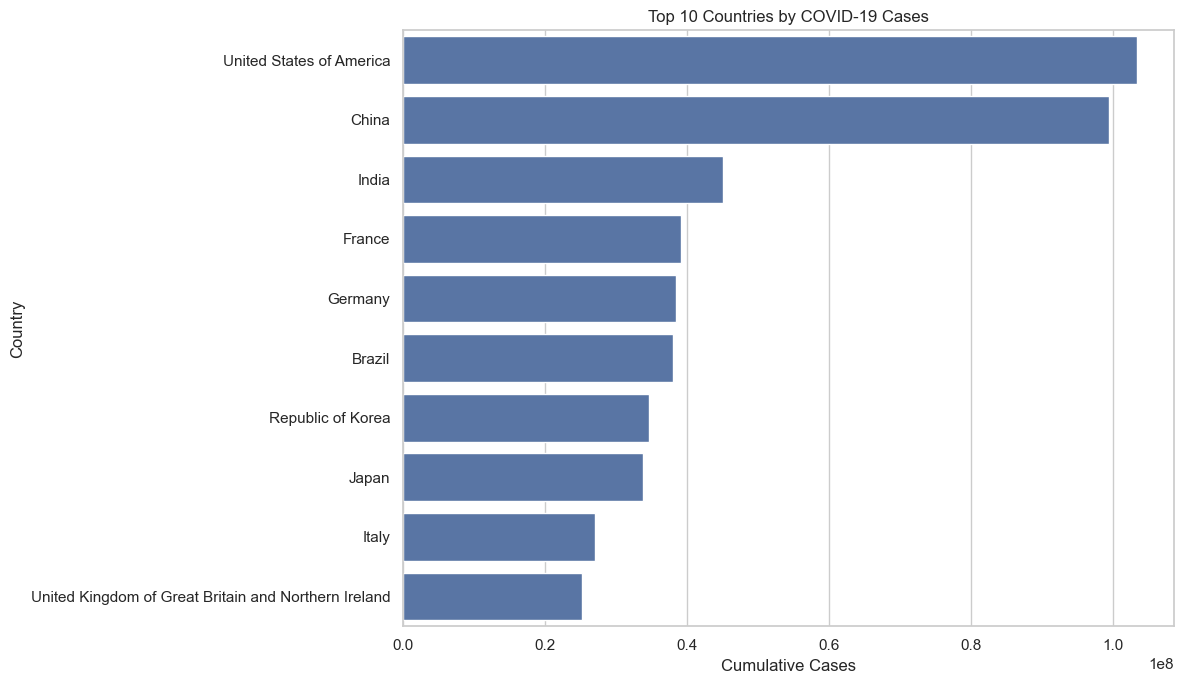

In [30]:
top_10_cases = country_cases.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_cases.values,
    y=top_10_cases.index
)

plt.title('Top 10 Countries by COVID-19 Cases')
plt.xlabel('Cumulative Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**17. Total deaths by country**

In [31]:
country_deaths = (
    df.groupby('Country')['Cumulative_deaths']
      .max()
      .sort_values(ascending=False)
)

display(country_deaths.head(20).to_frame('Total_Deaths'))

,Total_Deaths
Country,
United States of America,1238678
Brazil,704045
India,533849
Russian Federation,404290
Mexico,335111
United Kingdom of Great Britain and Northern Ireland,232112
Peru,221072
Italy,198523
Germany,174979


**18. Top 10 countries by deaths**

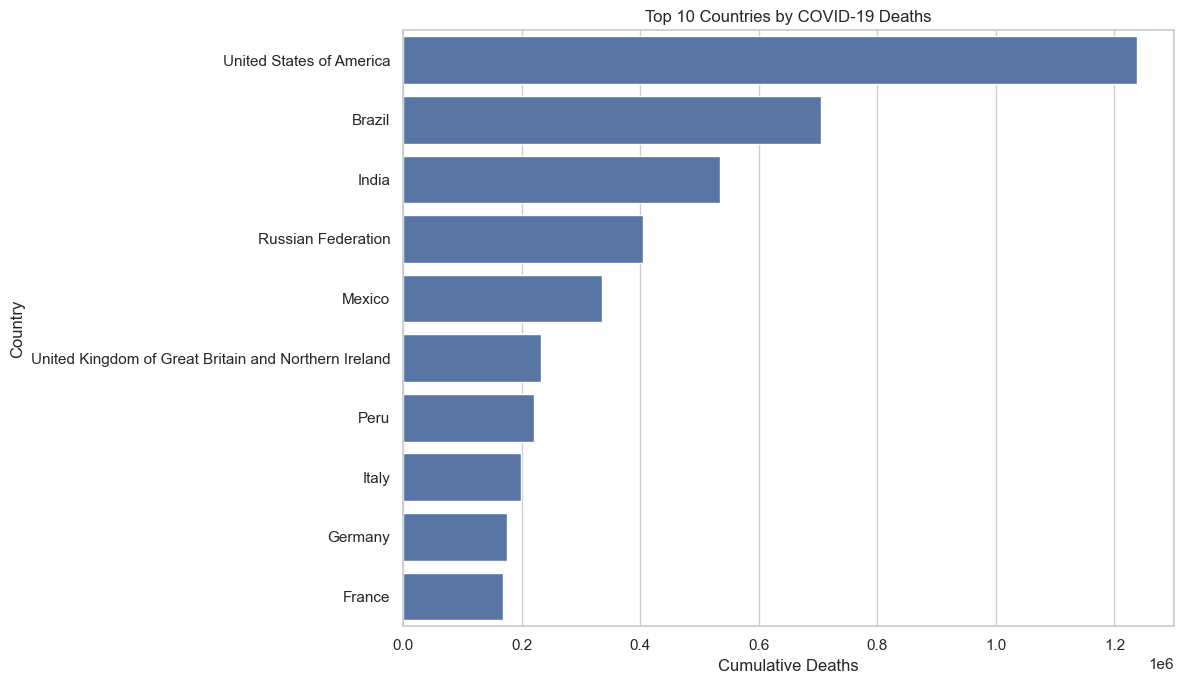

In [32]:
top_10_deaths = country_deaths.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_deaths.values,
    y=top_10_deaths.index
)

plt.title('Top 10 Countries by COVID-19 Deaths')
plt.xlabel('Cumulative Deaths')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**19. Create year and month columns**

In [33]:
df['Year'] = df['Date_reported'].dt.year
df['Month'] = df['Date_reported'].dt.month
df['Month_Name'] = df['Date_reported'].dt.month_name()

**20. Monthly new cases**

In [34]:
monthly_cases = (
    df.groupby(df['Date_reported'].dt.to_period('M'))['New_cases']
      .sum()
)

display(monthly_cases.to_frame('New_Cases'))

,New_Cases
Date_reported,
2020-01,9822.0
2020-02,75373.0
2020-03,697579.0
2020-04,2222868.0
2020-05,2886397.0
2020-06,4268400.0
2020-07,6973974.0
2020-08,8287922.0
2020-09,8625997.0


**21. Monthly cases trend**

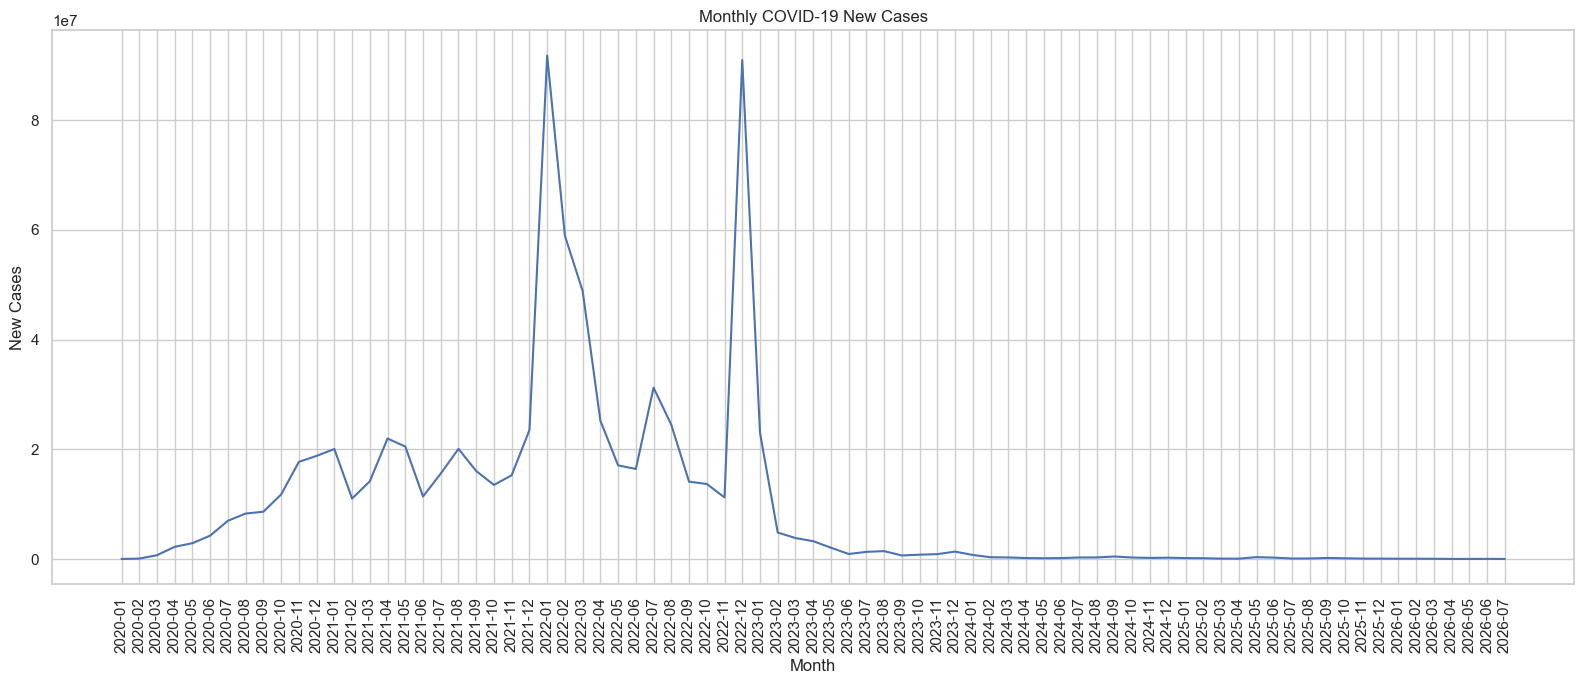

In [35]:
plt.figure(figsize=(16, 7))

plt.plot(
    monthly_cases.index.astype(str),
    monthly_cases.values
)

plt.title('Monthly COVID-19 New Cases')
plt.xlabel('Month')
plt.ylabel('New Cases')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**22. Monthly deaths**

In [36]:
monthly_deaths = (
    df.groupby(df['Date_reported'].dt.to_period('M'))['New_deaths']
      .sum()
)

display(monthly_deaths.to_frame('New_Deaths'))

,New_Deaths
Date_reported,
2020-01,219.0
2020-02,2717.0
2020-03,40666.0
2020-04,193544.0
2020-05,164357.0
2020-06,153673.0
2020-07,184438.0
2020-08,193839.0
2020-09,168307.0


**23. Monthly deaths trend**

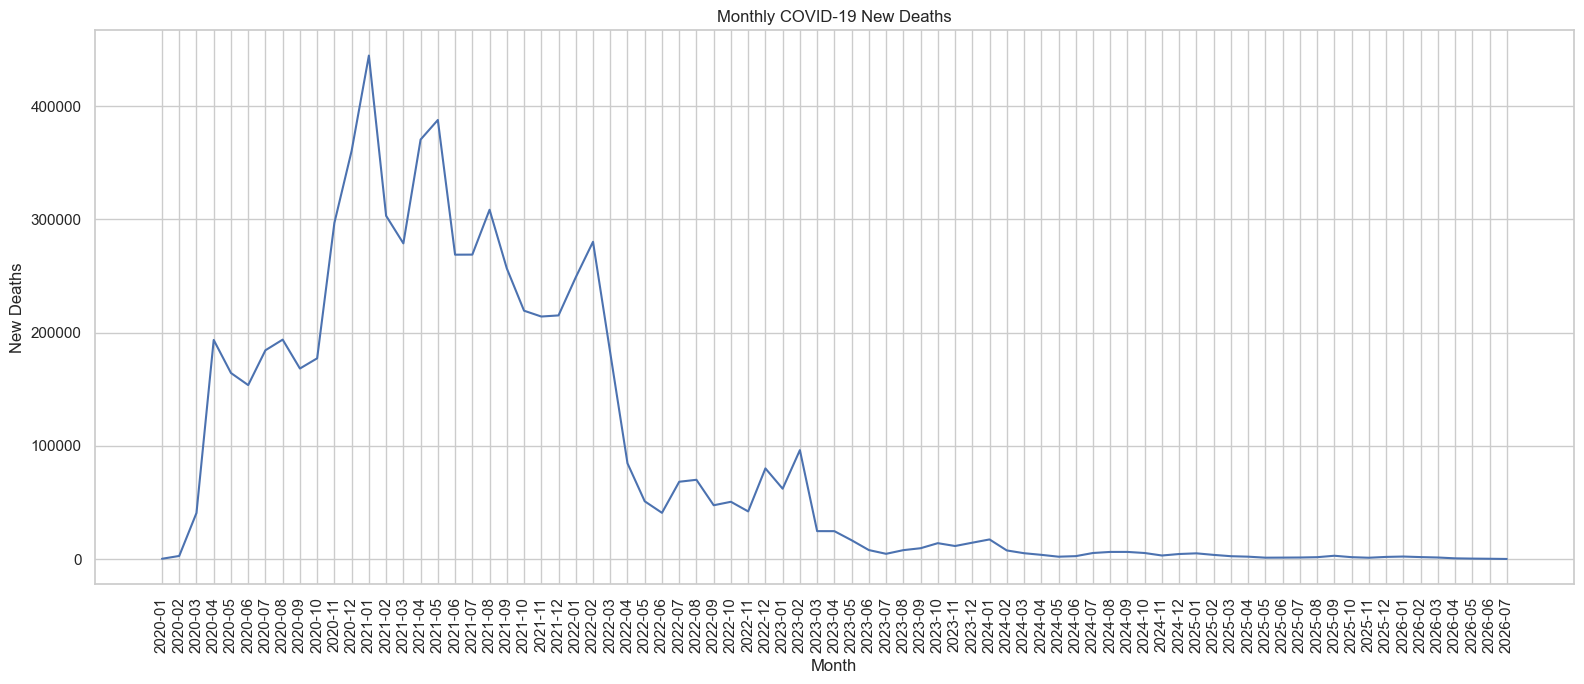

In [37]:
plt.figure(figsize=(16, 7))

plt.plot(
    monthly_deaths.index.astype(str),
    monthly_deaths.values
)

plt.title('Monthly COVID-19 New Deaths')
plt.xlabel('Month')
plt.ylabel('New Deaths')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**24. Yearly cases**

In [38]:
yearly_cases = (
    df.groupby('Year')['New_cases']
      .sum()
)

display(yearly_cases.to_frame('Total_New_Cases'))

,Total_New_Cases
Year,
2020,82335574.0
2021,203111242.0
2022,444029532.0
2023,44322098.0
2024,3558323.0
2025,1701424.0
2026,210053.0


**25. Yearly cases visualization**

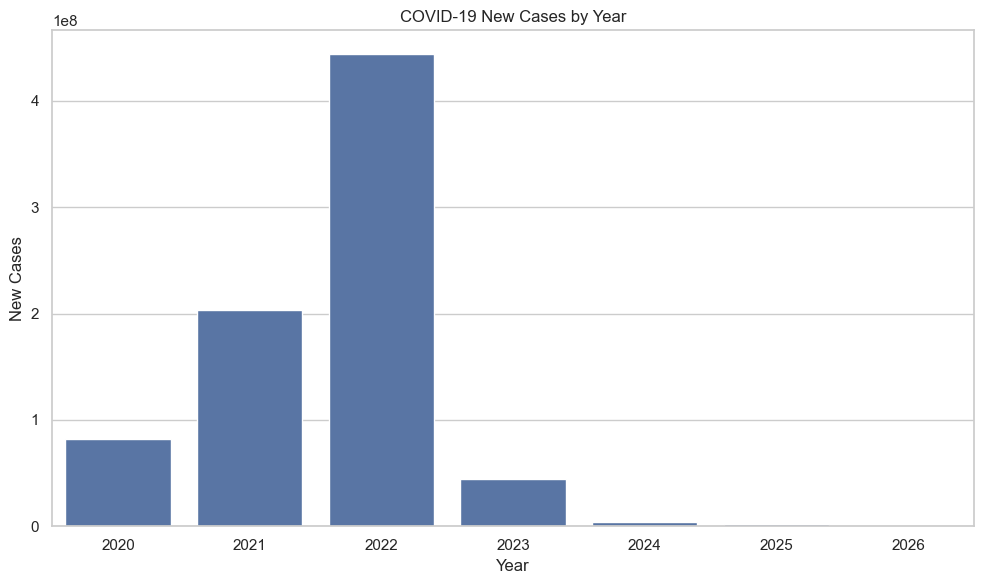

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=yearly_cases.index,
    y=yearly_cases.values
)

plt.title('COVID-19 New Cases by Year')
plt.xlabel('Year')
plt.ylabel('New Cases')

plt.tight_layout()
plt.show()

**26. Yearly deaths**

In [40]:
yearly_deaths = (
    df.groupby('Year')['New_deaths']
      .sum()
)

display(yearly_deaths.to_frame('Total_New_Deaths'))

,Total_New_Deaths
Year,
2020,1936752.0
2021,3537358.0
2022,1246156.0
2023,294000.0
2024,69075.0
2025,26190.0
2026,6520.0


**27. Yearly deaths visualization**

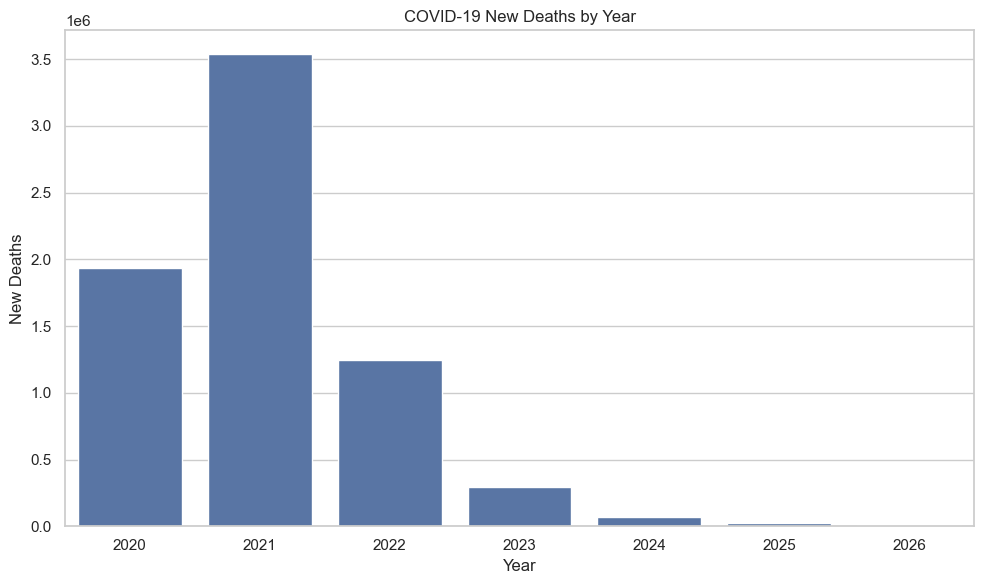

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=yearly_deaths.index,
    y=yearly_deaths.values
)

plt.title('COVID-19 New Deaths by Year')
plt.xlabel('Year')
plt.ylabel('New Deaths')

plt.tight_layout()
plt.show()

**28. Cases by WHO region**

In [42]:
region_cases = (
    df.groupby('WHO_region')['New_cases']
      .sum()
      .sort_values(ascending=False)
)

display(region_cases.to_frame('Total_New_Cases'))

,Total_New_Cases
WHO_region,
EUR,281760531.0
WPR,215441060.0
AMR,193905325.0
SEAR,55152460.0
EMR,23417911.0
AFR,9590195.0
OTHER,764.0


**29. Deaths by WHO region**

In [43]:
region_deaths = (
    df.groupby('WHO_region')['New_deaths']
      .sum()
      .sort_values(ascending=False)
)

display(region_deaths.to_frame('Total_New_Deaths'))

,Total_New_Deaths
WHO_region,
AMR,3074065.0
EUR,2283431.0
SEAR,647290.0
WPR,583745.0
EMR,351975.0
AFR,175532.0
OTHER,13.0


**30. Region cases visualization**

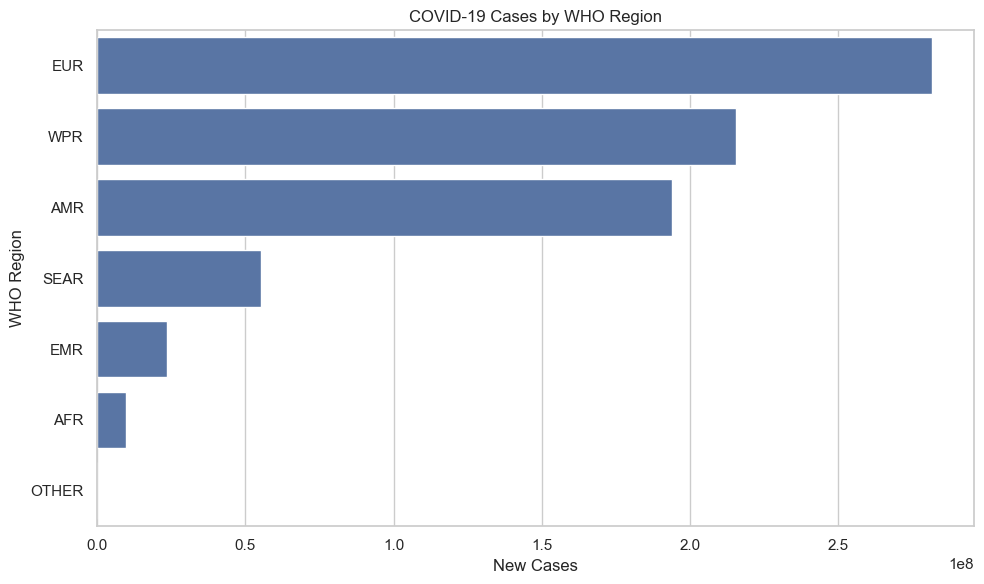

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_cases.values,
    y=region_cases.index
)

plt.title('COVID-19 Cases by WHO Region')
plt.xlabel('New Cases')
plt.ylabel('WHO Region')

plt.tight_layout()
plt.show()

**31. Calculate country-level fatality rate**

In [45]:
country_summary = df.groupby('Country').agg(
    Total_Cases=('Cumulative_cases', 'max'),
    Total_Deaths=('Cumulative_deaths', 'max')
)

country_summary['Case_Fatality_Rate_%'] = (
    country_summary['Total_Deaths'] /
    country_summary['Total_Cases']
) * 100

country_summary = country_summary.replace(
    [np.inf, -np.inf],
    np.nan
)

display(
    country_summary
    .sort_values('Case_Fatality_Rate_%', ascending=False)
    .head(20)
)

,Total_Cases,Total_Deaths,Case_Fatality_Rate_%
Country,,,
Yemen,11945,2159,18.074508
Sudan,63993,5046,7.885237
Syrian Arab Republic,57423,3163,5.508246
Somalia,27334,1361,4.979147
Peru,4533838,221072,4.876045
Egypt,516023,24830,4.811801
Mexico,7630870,335111,4.391518
Bosnia and Herzegovina,404289,16419,4.061204
Liberia,8090,294,3.634116


**32. Remove countries with very small case counts**

In [46]:
filtered_fatality = country_summary[
    country_summary['Total_Cases'] >= 10000
].copy()

display(
    filtered_fatality
    .sort_values('Case_Fatality_Rate_%', ascending=False)
    .head(20)
)

,Total_Cases,Total_Deaths,Case_Fatality_Rate_%
Country,,,
Yemen,11945,2159,18.074508
Sudan,63993,5046,7.885237
Syrian Arab Republic,57423,3163,5.508246
Somalia,27334,1361,4.979147
Peru,4533838,221072,4.876045
Egypt,516023,24830,4.811801
Mexico,7630870,335111,4.391518
Bosnia and Herzegovina,404289,16419,4.061204
Afghanistan,235214,7998,3.400308


**33. Correlation Analysis**

In [47]:
numeric_columns = [
    'New_cases',
    'Cumulative_cases',
    'New_deaths',
    'Cumulative_deaths'
]

correlation = df[numeric_columns].corr()

display(correlation)

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
New_cases,1.000000,0.147937,0.268430,0.149803
Cumulative_cases,0.147937,1.000000,0.183933,0.781339
New_deaths,0.268430,0.183933,1.000000,0.338930
Cumulative_deaths,0.149803,0.781339,0.338930,1.000000


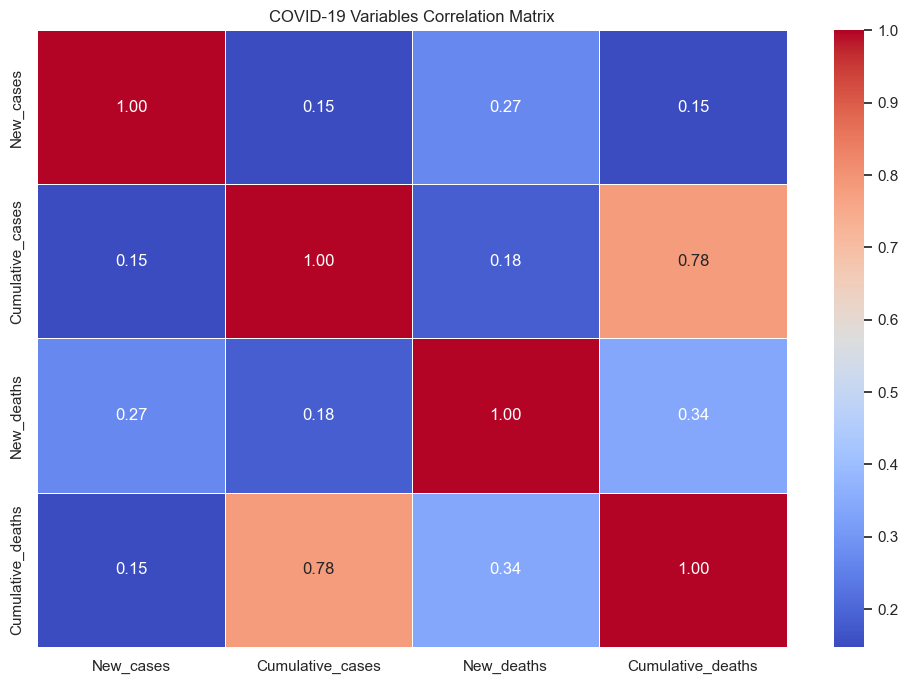

In [50]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('COVID-19 Variables Correlation Matrix')
plt.tight_layout()
plt.show()

**34. Distribution Analysis**

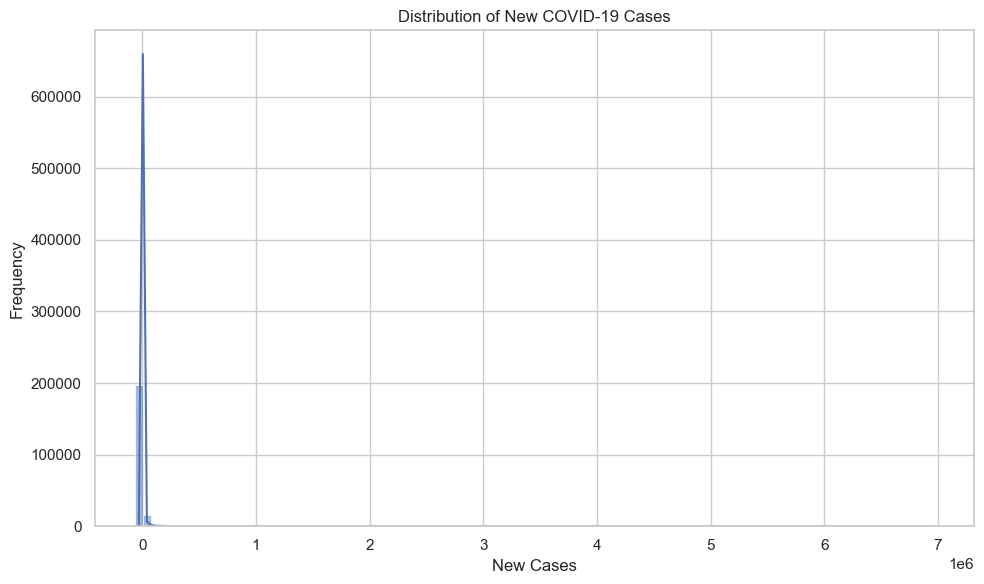

In [52]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['New_cases'].dropna(),
    bins=100,
    kde=True
)

plt.title('Distribution of New COVID-19 Cases')
plt.xlabel('New Cases')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

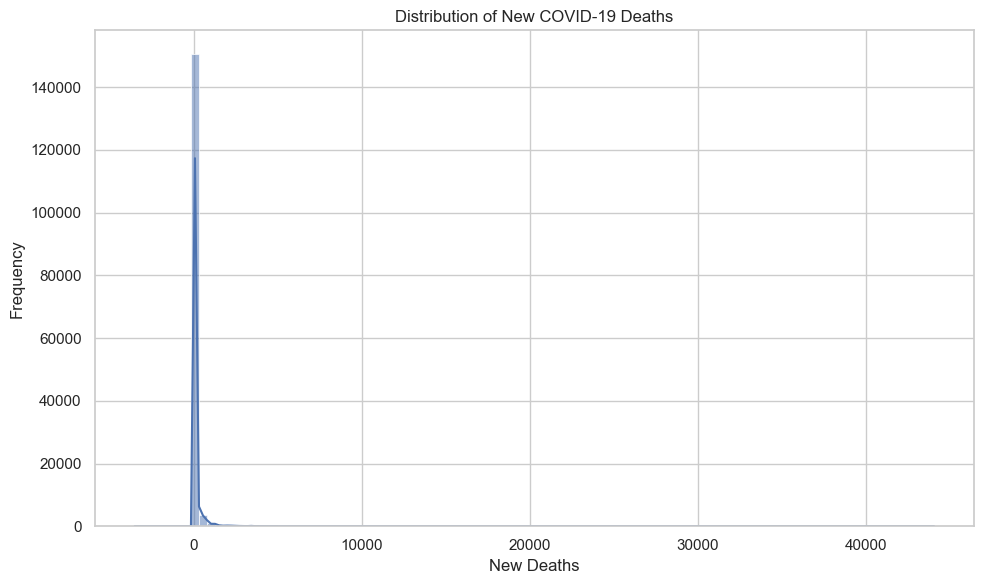

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['New_deaths'].dropna(),
    bins=100,
    kde=True
)

plt.title('Distribution of New COVID-19 Deaths')
plt.xlabel('New Deaths')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**35. Top Countries Combined Analysis**

In [54]:
country_analysis = df.groupby(
    ['Country', 'WHO_region']
).agg(
    Total_Cases=('Cumulative_cases', 'max'),
    Total_Deaths=('Cumulative_deaths', 'max'),
    Total_New_Cases=('New_cases', 'sum'),
    Total_New_Deaths=('New_deaths', 'sum')
).reset_index()

country_analysis['Fatality_Rate_%'] = (
    country_analysis['Total_Deaths'] /
    country_analysis['Total_Cases']
) * 100

country_analysis = country_analysis.replace(
    [np.inf, -np.inf],
    np.nan
)

display(country_analysis.head())

,Country,WHO_region,Total_Cases,Total_Deaths,Total_New_Cases,Total_New_Deaths,Fatality_Rate_%
0,Afghanistan,EMR,235214,7998,235214.0,7998.0,3.400308
1,Albania,EUR,337234,3608,337234.0,3608.0,1.069880
2,Algeria,AFR,272440,6881,272440.0,6881.0,2.525694
3,American Samoa,WPR,8359,34,8359.0,34.0,0.406747
4,Andorra,EUR,48015,159,48015.0,159.0,0.331147


In [55]:
top_countries = (
    country_analysis
    .sort_values('Total_Cases', ascending=False)
    .head(20)
)

display(top_countries)

,Country,WHO_region,Total_Cases,Total_Deaths,Total_New_Cases,Total_New_Deaths,Fatality_Rate_%
229,United States of America,AMR,103436829,1238678,103436829.0,1238678.0,1.197521
42,China,WPR,99381761,122398,99381761.0,122398.0,0.123159
96,India,SEAR,45056221,533849,45056221.0,533849.0,1.184851
72,France,EUR,39060935,168207,39060935.0,168207.0,0.430627
78,Germany,EUR,38437953,174979,38437953.0,174979.0,0.455225
28,Brazil,AMR,38042729,704045,38042729.0,704045.0,1.850669
175,Republic of Korea,WPR,34571873,35934,34571873.0,35934.0,0.103940
111,Japan,WPR,33803572,74694,33803572.0,74694.0,0.220965
109,Italy,EUR,26969918,198523,26969918.0,198523.0,0.736090
226,United Kingdom of Great Britain and Northern I...,EUR,25118508,232112,25118508.0,232112.0,0.924068


**36. Advanced Visualization**

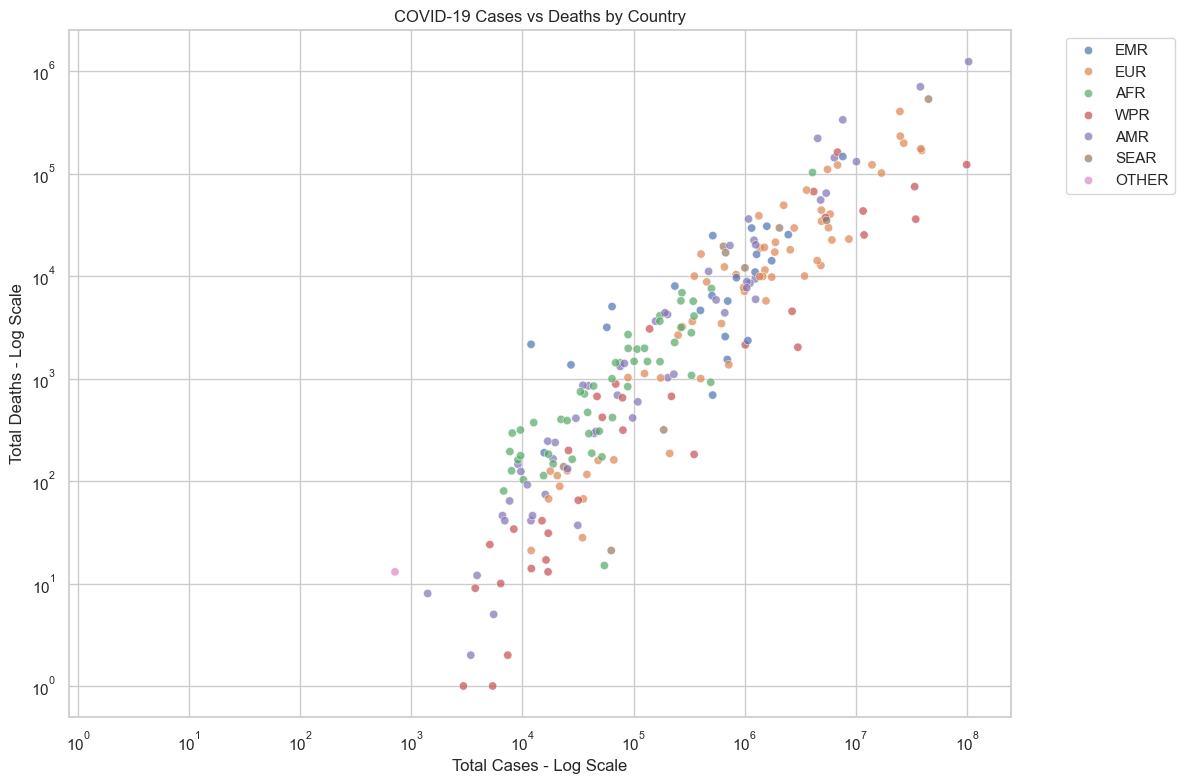

In [56]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=country_analysis[
        country_analysis['Total_Cases'] > 0
    ],
    x='Total_Cases',
    y='Total_Deaths',
    hue='WHO_region',
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')

plt.title('COVID-19 Cases vs Deaths by Country')
plt.xlabel('Total Cases - Log Scale')
plt.ylabel('Total Deaths - Log Scale')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

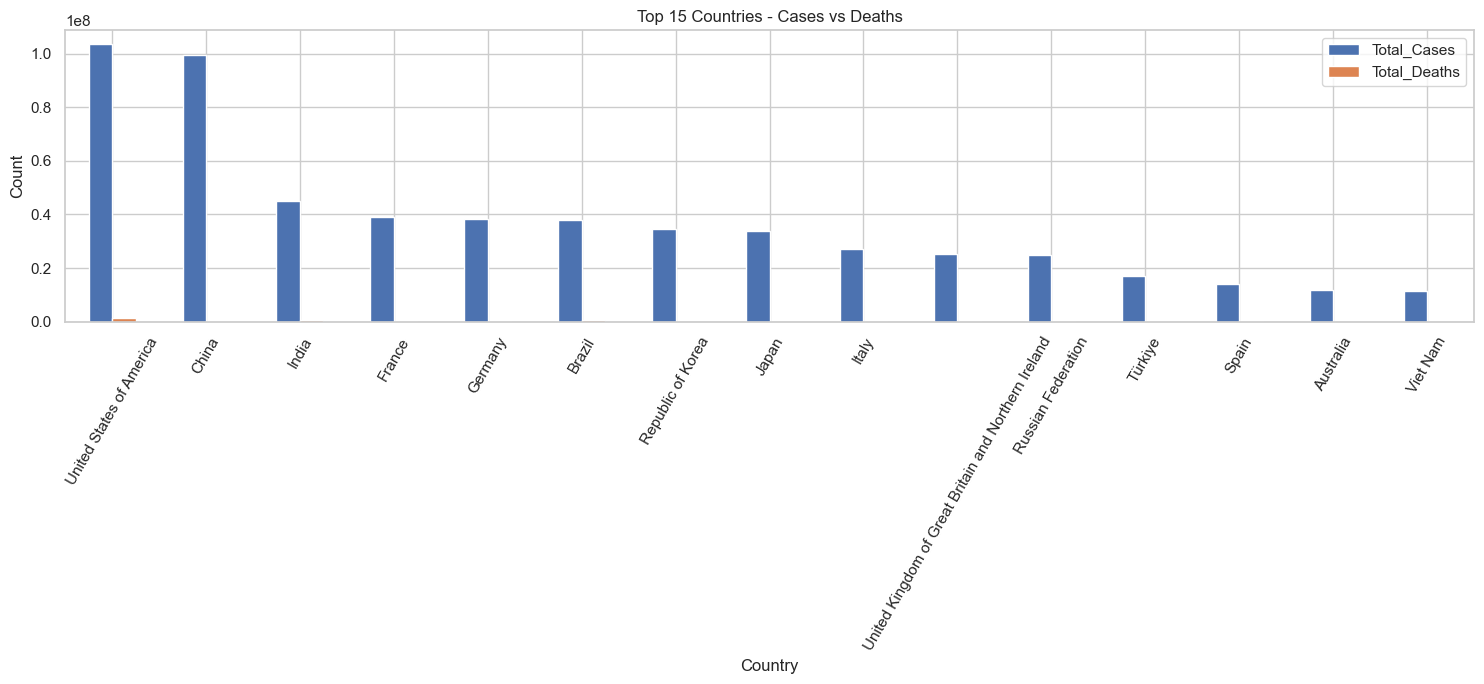

In [57]:
top15 = (
    country_analysis
    .sort_values('Total_Cases', ascending=False)
    .head(15)
)

plot_data = top15.set_index('Country')[
    ['Total_Cases', 'Total_Deaths']
]

plot_data.plot(
    kind='bar',
    figsize=(15, 7)
)

plt.title('Top 15 Countries - Cases vs Deaths')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

**37. India Analysis**

In [58]:
india = df[df['Country'] == 'India'].copy()

print("India records:", len(india))

display(india.head())

India records: 2389


,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Year,Month,Month_Name
111,2020-01-04,IN,India,SEAR,0.0,0,0.0,0,2020,1,January
423,2020-01-05,IN,India,SEAR,0.0,0,0.0,0,2020,1,January
591,2020-01-06,IN,India,SEAR,0.0,0,0.0,0,2020,1,January
903,2020-01-07,IN,India,SEAR,0.0,0,0.0,0,2020,1,January
1071,2020-01-08,IN,India,SEAR,0.0,0,0.0,0,2020,1,January


In [59]:
india_total_cases = india['Cumulative_cases'].max()
india_total_deaths = india['Cumulative_deaths'].max()

print(f"India Total Cases  : {india_total_cases:,.0f}")
print(f"India Total Deaths : {india_total_deaths:,.0f}")

if india_total_cases > 0:
    india_cfr = (india_total_deaths / india_total_cases) * 100
    print(f"India Case Fatality Rate: {india_cfr:.2f}%")

India Total Cases  : 45,056,221
India Total Deaths : 533,849
India Case Fatality Rate: 1.18%


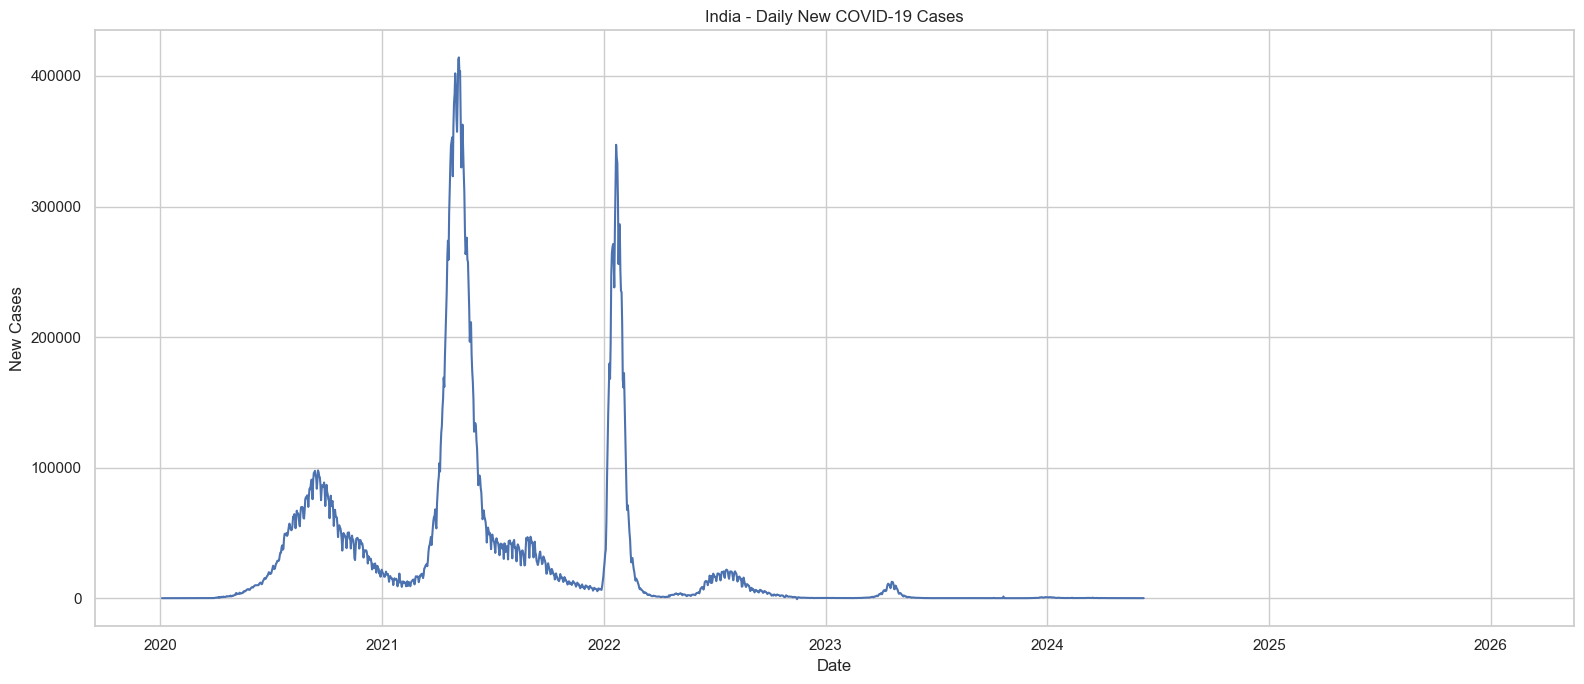

In [60]:
plt.figure(figsize=(16, 7))

plt.plot(
    india['Date_reported'],
    india['New_cases']
)

plt.title('India - Daily New COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('New Cases')

plt.tight_layout()
plt.show()

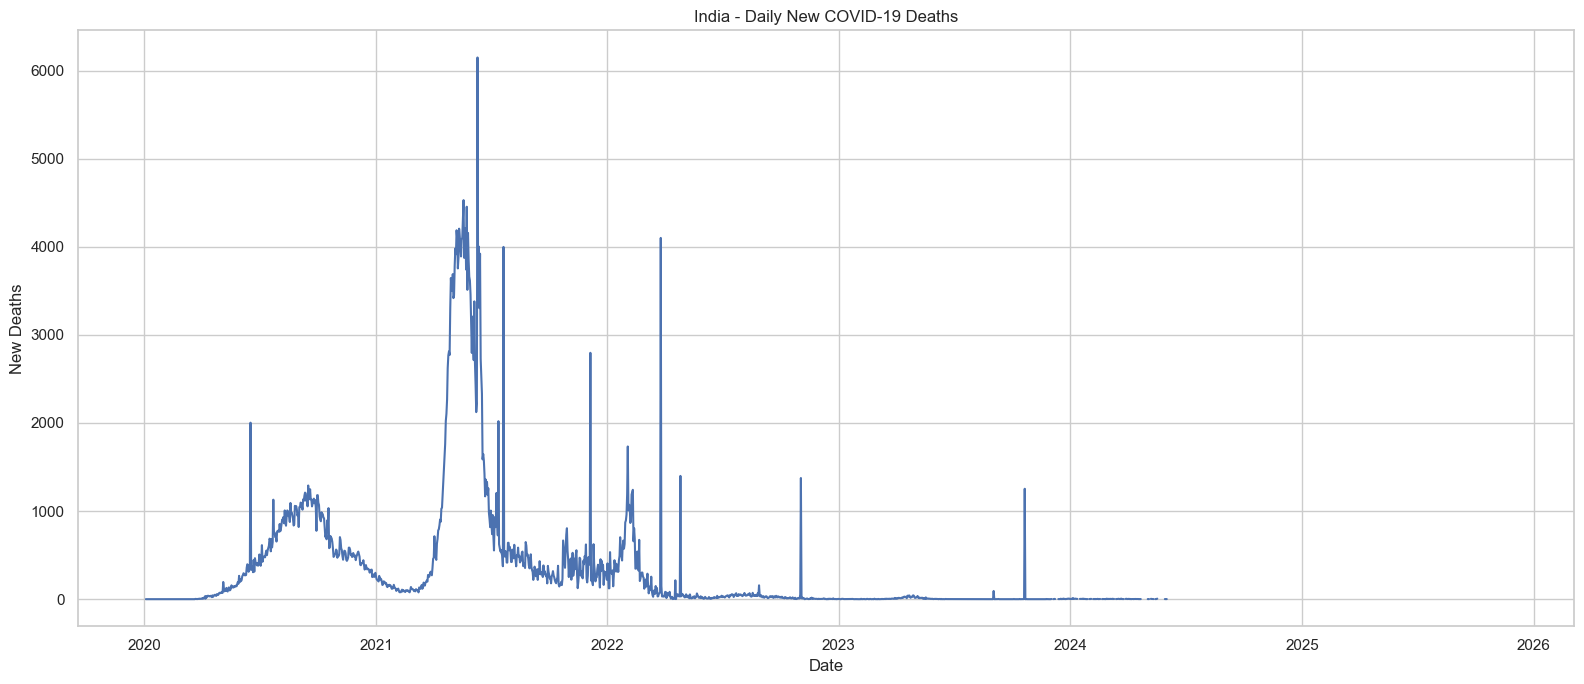

In [61]:
plt.figure(figsize=(16, 7))

plt.plot(
    india['Date_reported'],
    india['New_deaths']
)

plt.title('India - Daily New COVID-19 Deaths')
plt.xlabel('Date')
plt.ylabel('New Deaths')

plt.tight_layout()
plt.show()

**38. 7-Day Moving Average**

In [62]:
india = india.sort_values('Date_reported')

india['Cases_7_Day_MA'] = (
    india['New_cases']
    .rolling(window=7)
    .mean()
)

india['Deaths_7_Day_MA'] = (
    india['New_deaths']
    .rolling(window=7)
    .mean()
)

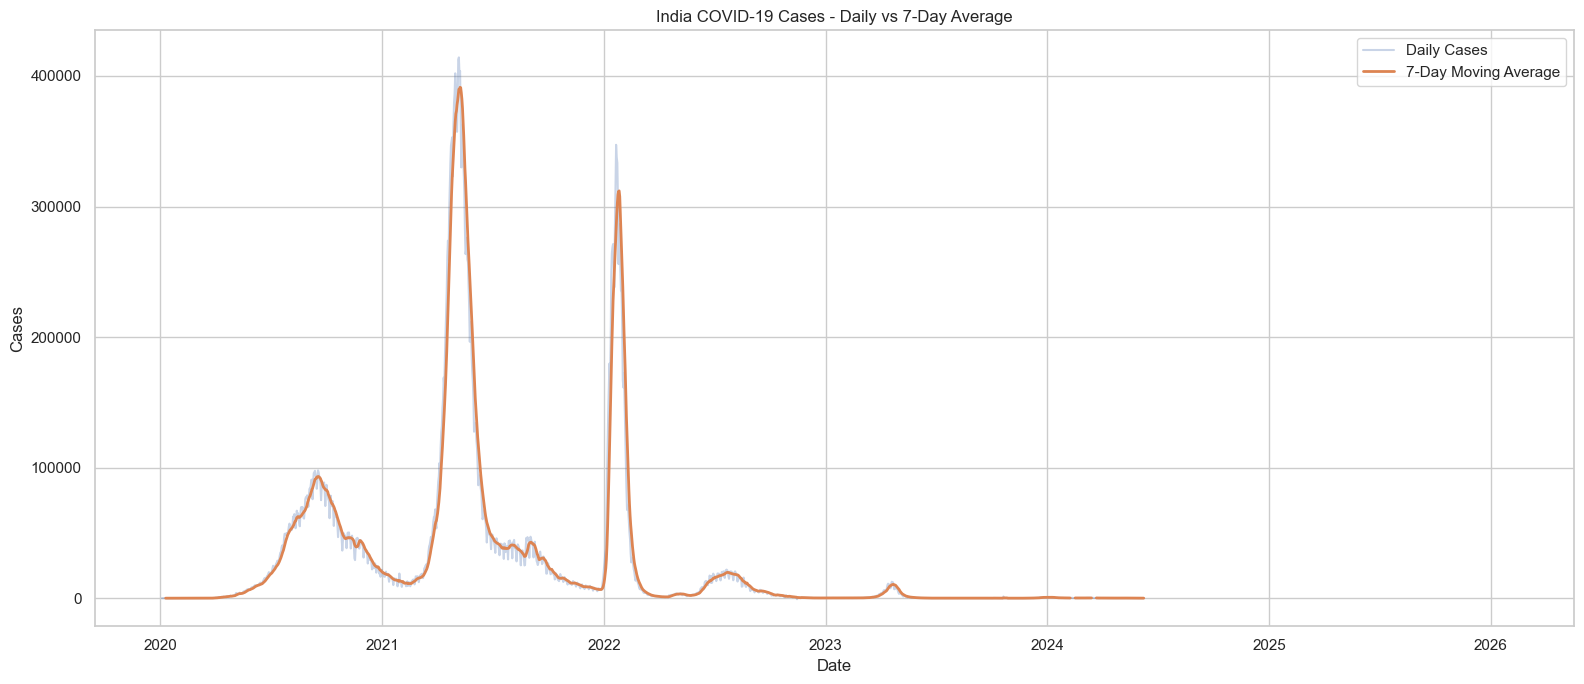

In [63]:
plt.figure(figsize=(16, 7))

plt.plot(
    india['Date_reported'],
    india['New_cases'],
    alpha=0.3,
    label='Daily Cases'
)

plt.plot(
    india['Date_reported'],
    india['Cases_7_Day_MA'],
    linewidth=2,
    label='7-Day Moving Average'
)

plt.title('India COVID-19 Cases - Daily vs 7-Day Average')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()

plt.tight_layout()
plt.show()

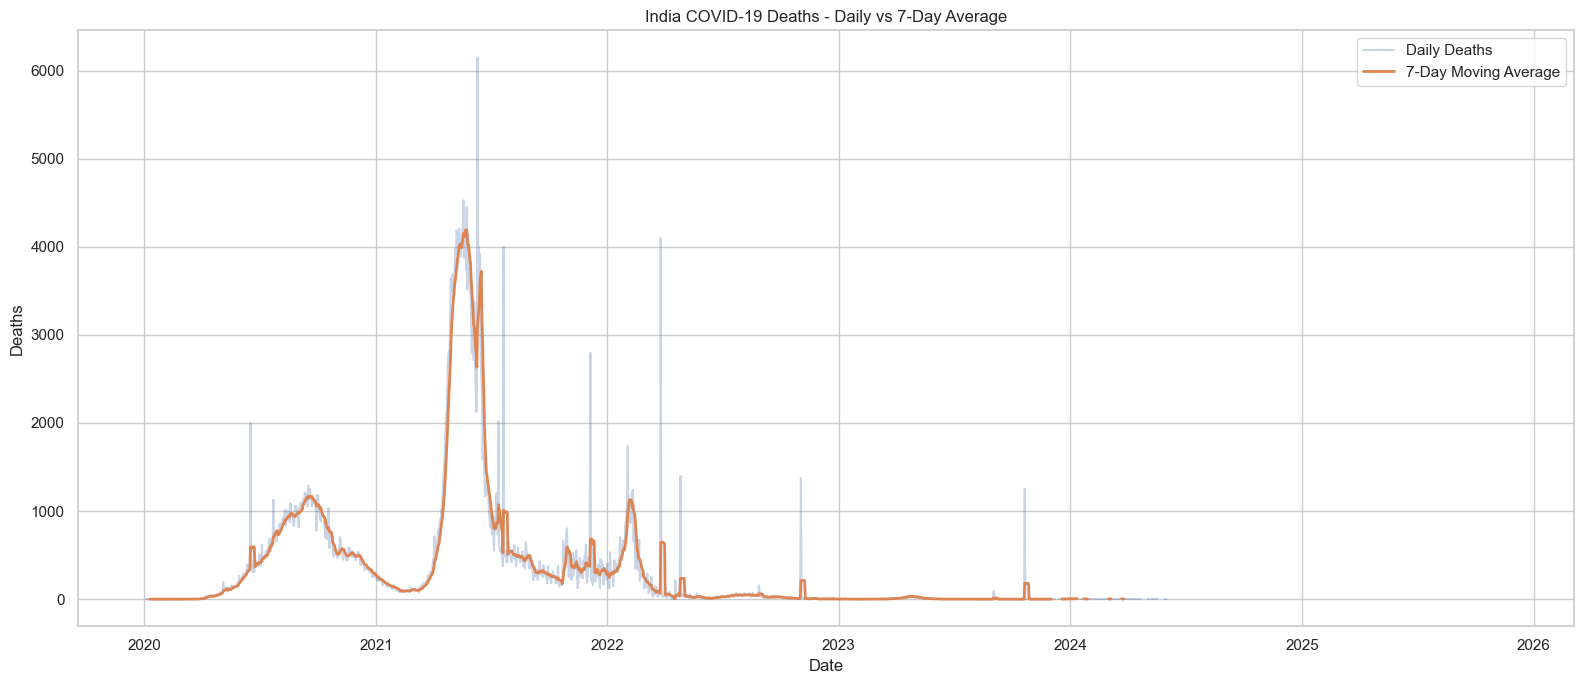

In [64]:
plt.figure(figsize=(16, 7))

plt.plot(
    india['Date_reported'],
    india['New_deaths'],
    alpha=0.3,
    label='Daily Deaths'
)

plt.plot(
    india['Date_reported'],
    india['Deaths_7_Day_MA'],
    linewidth=2,
    label='7-Day Moving Average'
)

plt.title('India COVID-19 Deaths - Daily vs 7-Day Average')
plt.xlabel('Date')
plt.ylabel('Deaths')
plt.legend()

plt.tight_layout()
plt.show()

**39. Find Peak COVID Periods**

In [65]:
peak_cases = (
    india[['Date_reported', 'New_cases']]
    .dropna()
    .sort_values('New_cases', ascending=False)
    .head(10)
)

display(peak_cases)

,Date_reported,New_cases
117539,2021-05-07,414188.0
117235,2021-05-06,412262.0
118023,2021-05-09,403738.0
116103,2021-05-01,401993.0
117711,2021-05-08,401078.0
116275,2021-05-02,392488.0
115795,2021-04-30,386452.0
117059,2021-05-05,382315.0
115623,2021-04-29,379257.0
116583,2021-05-03,368147.0


In [66]:
peak_deaths = (
    india[['Date_reported', 'New_deaths']]
    .dropna()
    .sort_values('New_deaths', ascending=False)
    .head(10)
)

display(peak_deaths)

,Date_reported,New_deaths
125699,2021-06-10,6148.0
120423,2021-05-19,4529.0
121555,2021-05-24,4454.0
120115,2021-05-18,4329.0
120899,2021-05-21,4209.0
118671,2021-05-12,4205.0
121075,2021-05-22,4194.0
117711,2021-05-08,4187.0
122031,2021-05-26,4157.0
118983,2021-05-13,4120.0


**40. Automated Data Quality Check**

In [67]:
data_quality = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str).values,
    'Missing_Count': df.isnull().sum().values,
    'Missing_%': (
        df.isnull().sum().values / len(df) * 100
    ),
    'Unique_Values': [
        df[col].nunique()
        for col in df.columns
    ]
})

display(data_quality)

,Column,Data_Type,Missing_Count,Missing_%,Unique_Values
0,Date_reported,datetime64[ns],0,0.000000,2389
1,Country_code,object,2389,0.416667,239
2,Country,object,0,0.000000,240
3,WHO_region,object,0,0.000000,7
4,New_cases,float64,358789,62.576566,18372
5,Cumulative_cases,int64,0,0.000000,130942
6,New_deaths,float64,417263,72.775045,1899
7,Cumulative_deaths,int64,0,0.000000,41424
8,Year,int32,0,0.000000,7
9,Month,int32,0,0.000000,12


**41. Automated Data Quality Check**

In [69]:
df.to_excel("COVID-19_Cleaned.xlsx",index=False)